In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet(r'E:\finsight\data\processed\loans_clean.parquet')
print(f"Loaded: {df.shape}")
print(f"Default rate: {df['TARGET'].mean()*100:.2f}%")
print(f"\nColumns available: {df.shape[1]}")

Loaded: (1328284, 88)
Default rate: 21.41%

Columns available: 88


Features selected: 26
Features used: ['loan_amnt', 'int_rate', 'installment', 'term_months', 'annual_inc', 'dti', 'emp_length_num', 'delinq_2yrs', 'open_acc', 'revol_util', 'revol_bal', 'pub_rec', 'inq_last_6mths', 'total_acc', 'income_to_loan', 'dti_risk_flag', 'rate_grade_spread', 'has_delinquency', 'loan_to_income_pct', 'is_high_grade', 'has_pub_rec', 'high_revol_util', 'grade', 'purpose', 'home_ownership', 'verification_status']

Encoding: ['grade', 'purpose', 'home_ownership', 'verification_status']

Train: (1062627, 26), Test: (265657, 26)
Train default rate: 21.41%
Test default rate:  21.41%

Class ratio — Paid: 835,152 | Defaulted: 227,475 | Scale weight: 3.67

Training XGBoost... (this will take 3-5 minutes)
[0]	validation_0-auc:0.69461
[50]	validation_0-auc:0.70699
[100]	validation_0-auc:0.71236
[150]	validation_0-auc:0.71516
[200]	validation_0-auc:0.71669
[250]	validation_0-auc:0.71762
[299]	validation_0-auc:0.71859

AUC-ROC: 0.7186

Classification Report:
              prec

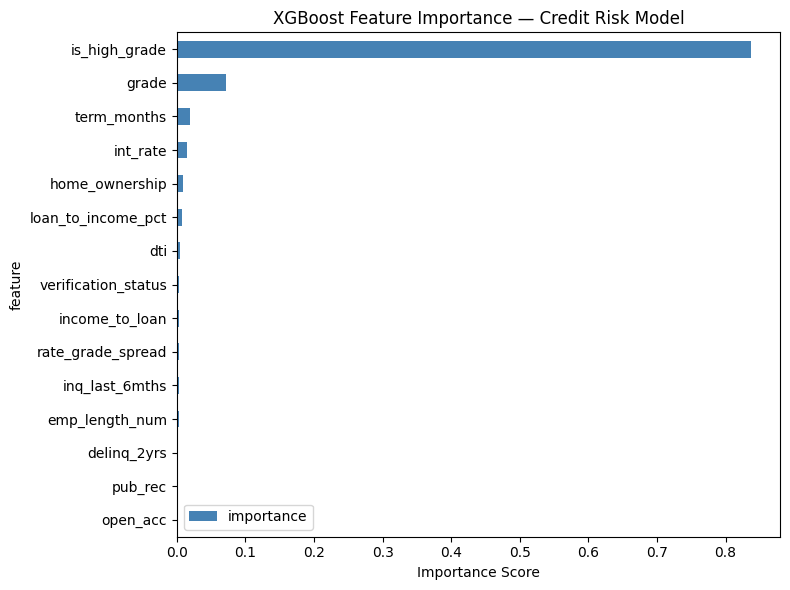


Risk tier distribution:
risk_tier
Low          66460
Medium      229784
High        463515
Critical    568525
Name: count, dtype: int64

✓ Model saved to models/credit_risk_model.pkl
✓ Scored dataset saved to data/outputs/loans_scored.parquet


In [2]:
# ── Feature selection ───────────────────────────────────────────────
feature_cols = [
    # Loan characteristics
    'loan_amnt', 'int_rate', 'installment', 'term_months',
    # Borrower profile
    'annual_inc', 'dti', 'emp_length_num',
    # Credit bureau signals
    'delinq_2yrs', 'open_acc', 'revol_util', 'revol_bal',
    'pub_rec', 'inq_last_6mths', 'total_acc',
    # Engineered features
    'income_to_loan', 'dti_risk_flag', 'rate_grade_spread',
    'has_delinquency', 'loan_to_income_pct', 'is_high_grade',
    'has_pub_rec', 'high_revol_util',
    # Categorical
    'grade', 'purpose', 'home_ownership', 'verification_status'
]

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df.columns]
print(f"Features selected: {len(feature_cols)}")
print(f"Features used: {feature_cols}")

model_df = df[feature_cols + ['TARGET']].copy()

# ── Encode categoricals ─────────────────────────────────────────────
le_dict = {}
cat_cols = model_df.select_dtypes('object').columns.tolist()
print(f"\nEncoding: {cat_cols}")
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype('str'))
    le_dict[col] = le

# ── Train / test split ──────────────────────────────────────────────
X = model_df.drop(columns=['TARGET'])
y = model_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:  {y_test.mean()*100:.2f}%")

# ── Class imbalance ratio ───────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"\nClass ratio — Paid: {neg:,} | Defaulted: {pos:,} | Scale weight: {scale:.2f}")

# ── Train XGBoost ───────────────────────────────────────────────────
print("\nTraining XGBoost... (this will take 3-5 minutes)")

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# ── Evaluate ────────────────────────────────────────────────────────
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba > 0.4).astype('int')

auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n{'='*50}")
print(f"AUC-ROC: {auc:.4f}")
print(f"{'='*50}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fully Paid', 'Defaulted']))

# ── Feature importance ──────────────────────────────────────────────
feat_imp = pd.DataFrame({
    'feature':    X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feat_imp.head(10).to_string(index=False))

# ── Plot feature importance ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.head(15).sort_values('importance').plot(
    x='feature', y='importance', kind='barh',
    color='steelblue', ax=ax
)
ax.set_title('XGBoost Feature Importance — Credit Risk Model')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r'E:\finsight\reports\feature_importance.png', dpi=150)
plt.show()

# ── Save model + scored dataset ─────────────────────────────────────
with open(r'E:\finsight\models\credit_risk_model.pkl', 'wb') as f:
    pickle.dump(model, f)

df_scored = model_df.copy()
df_scored['risk_score'] = model.predict_proba(X)[:, 1]
df_scored['risk_tier']  = pd.cut(
    df_scored['risk_score'],
    bins=[0, 0.15, 0.30, 0.50, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)
df_scored.to_parquet(r'E:\finsight\data\outputs\loans_scored.parquet', index=False)

print(f"\nRisk tier distribution:")
print(df_scored['risk_tier'].value_counts().sort_index())
print(f"\n✓ Model saved to models/credit_risk_model.pkl")
print(f"✓ Scored dataset saved to data/outputs/loans_scored.parquet")

In [3]:
# ── Retrain without is_high_grade ──────────────────────────────────
feature_cols_v2 = [c for c in feature_cols if c != 'is_high_grade']

model_df2 = df[feature_cols_v2 + ['TARGET']].copy()

cat_cols = model_df2.select_dtypes('object').columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    model_df2[col] = le.fit_transform(model_df2[col].astype('str'))

X2 = model_df2.drop(columns=['TARGET'])
y2 = model_df2['TARGET']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

neg2 = (y2_train == 0).sum()
pos2 = (y2_train == 1).sum()

print("Retraining without is_high_grade...")

model2 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=neg2/pos2,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)
model2.fit(X2_train, y2_train,
           eval_set=[(X2_test, y2_test)],
           verbose=50)

y2_proba = model2.predict_proba(X2_test)[:, 1]
print(f"\nAUC-ROC v2: {roc_auc_score(y2_test, y2_proba):.4f}")

feat_imp2 = pd.DataFrame({
    'feature':    X2.columns,
    'importance': model2.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features (v2):")
print(feat_imp2.head(10).to_string(index=False))

# ── Update saved files with v2 model ───────────────────────────────
with open(r'E:\finsight\models\credit_risk_model.pkl', 'wb') as f:
    pickle.dump(model2, f)

df_scored2 = model_df2.copy()
df_scored2['risk_score'] = model2.predict_proba(X2)[:, 1]
df_scored2['risk_tier']  = pd.cut(
    df_scored2['risk_score'],
    bins=[0, 0.15, 0.30, 0.50, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)
df_scored2.to_parquet(r'E:\finsight\data\outputs\loans_scored.parquet', index=False)

print(f"\nRisk tier distribution (v2):")
print(df_scored2['risk_tier'].value_counts().sort_index())
print("\n✓ v2 model and scored dataset saved")

Retraining without is_high_grade...
[0]	validation_0-auc:0.69461
[50]	validation_0-auc:0.70699
[100]	validation_0-auc:0.71236
[150]	validation_0-auc:0.71516
[200]	validation_0-auc:0.71669
[250]	validation_0-auc:0.71762
[299]	validation_0-auc:0.71859

AUC-ROC v2: 0.7186

Top 10 Features (v2):
            feature  importance
              grade    0.781967
        term_months    0.047713
           int_rate    0.035656
     home_ownership    0.022027
 loan_to_income_pct    0.018749
                dti    0.010081
verification_status    0.009470
     income_to_loan    0.009363
  rate_grade_spread    0.007055
     inq_last_6mths    0.006876

Risk tier distribution (v2):
risk_tier
Low          66460
Medium      229784
High        463515
Critical    568525
Name: count, dtype: int64

✓ v2 model and scored dataset saved
